In [15]:
from pathlib import Path
import MDAnalysis as mda
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import trvdos as vd

# topol / traj paths (REPLACE w/ dropbox link)
path = (Path("..") / ".." / "trvdos" / "tests" / "inputs").resolve()
TOPOL = path / "run-NVE.tpr"
TRAJ = path / "run-NVE_trunc.trr"

In [16]:
# Set up universe, unwrap traj, and select POPC atoms for VDOS object

u = mda.Universe(TOPOL, TRAJ)
unwrap = vd.unwrap(u)

sel = u.select_atoms("resname POPC")

# Create vdos object with a max lag time (nCorr) of 10 frames
vdos = vd.vdos(sel, 10)

building intra-molecular bond trees ...
unwrap -> detected 8016 molecules
unwrap -> tree building time: 0.37s
unwrap -> ready to unwrap


In [17]:
# Step through trajectory, calculate VDoS at each frame
t_step = 0
for ts in tqdm(u.trajectory, total=len(u.trajectory)):
    unwrap.single_frame()
    vdos.single_frame(t_step, ts.time)
    t_step += 1

100%|██████████| 32/32 [00:00<00:00, 90.83it/s]


In [18]:
vdos.copyResidueList()

# Collect the accumlated VaCFs and calculate VDoS - modes:
# all: all-residue average plus per-residue
# total: average only
# single: per-residue only
# total+single: all-residue average and per-residue average
vdos.postProcess(vdos.residueListCopy, mode="all")

# write residueproperties, VACF and VDoS out to text files if desired
out_dir = Path(".").resolve()
vdos.outputGeometry(out_dir / "residueProperties.dat", vdos.residueListCopy)
vdos.outputVACF(out_dir / "VACF.dat")
vdos.outputVDoS(out_dir / "VDoS.dat")

# Wavenumber and correlation time arrays are available in vdos.wavenumber 
# and vdos.tau resepectively
print(f"Wavenumber axis spans 0 – {vdos.wavenumber[-1]:.1f} cm⁻¹")
print(f"Correlation time axis spans 0 – {vdos.tau[-1]:.3f} ps")

Wavenumber axis spans 0 – 1975.1 cm⁻¹
Correlation time axis spans 0 – 0.072 ps


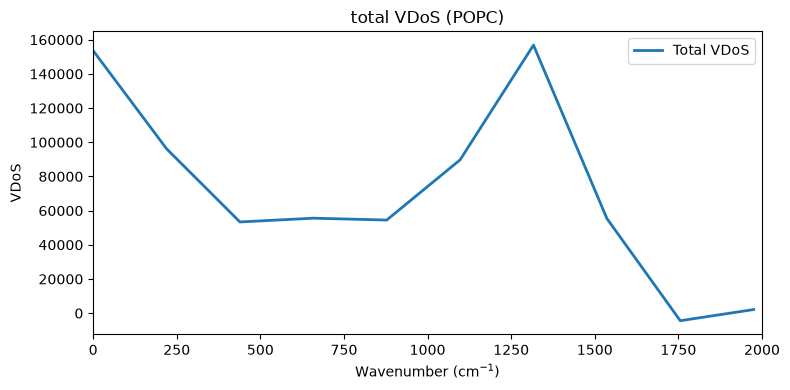

In [19]:
# the all-residue average vdos is stored in vdos.totVDoS[0]

tot_vdos = np.array(vdos.totVDoS[0])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(vdos.wavenumber, tot_vdos, linewidth=2.0, color="C0", label="Total VDoS")
ax.set(
    xlabel="Wavenumber (cm$^{-1}$)",
    ylabel="VDoS",
    title="total VDoS (POPC)",
    xlim=(0, 2000),
)
ax.legend()
fig.tight_layout()
plt.show()

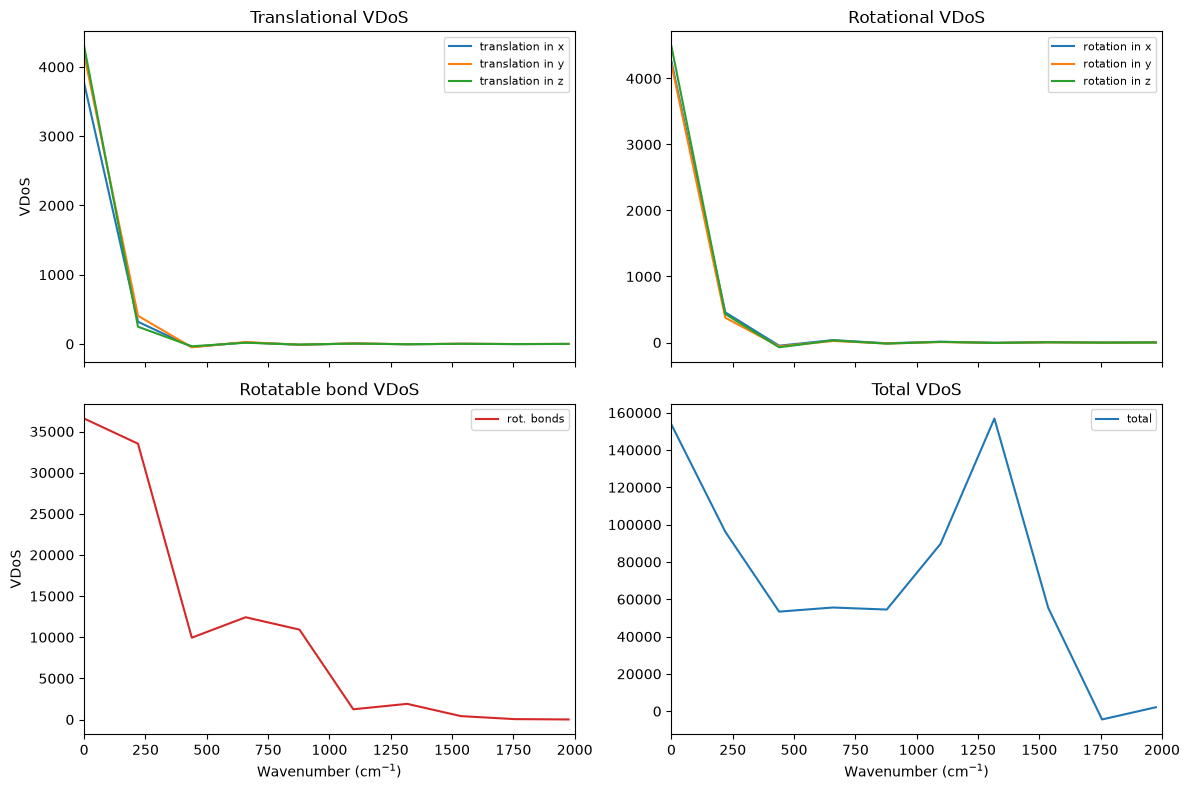

In [20]:
# Individual VDoS components are also available:
# translational VDoS: vdos.trVDoS[][ax]
# rotational VDoS: vdos.rotVDoS[][ax]
# rotable bond VDoS: vdos.rotBondVDoS[][ax]
axis_labels = ["x", "y", "z"]
colors = ["C0", "C1", "C2"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

# Translation
ax = axes[0, 0]
for j, (label, color) in enumerate(zip(axis_labels, colors)):
    ax.plot(vdos.wavenumber, vdos.trVDoS[0][j], label=f"translation in {label}", color=color)
ax.set(title="Translational VDoS", ylabel="VDoS")
ax.legend(fontsize=8)
ax.set_xlim(0, 2000)

# Rotation
ax = axes[0, 1]
for j, (label, color) in enumerate(zip(axis_labels, colors)):
    ax.plot(vdos.wavenumber, vdos.rotVDoS[0][j], label=f"rotation in {label}", color=color)
ax.set(title="Rotational VDoS")
ax.legend(fontsize=8)
ax.set_xlim(0, 2000)

# Rotatable bonds
ax = axes[1, 0]
ax.plot(vdos.wavenumber, vdos.rotBondVDoS[0], color="C3", label="rot. bonds")
ax.set(title="Rotatable bond VDoS", xlabel="Wavenumber (cm$^{-1}$)", ylabel="VDoS")
ax.legend(fontsize=8)
ax.set_xlim(0, 2000)

# Total (for reference in the grid)
ax = axes[1, 1]
ax.plot(vdos.wavenumber, tot_vdos, color="C0", label="total")
ax.set(title="Total VDoS", xlabel="Wavenumber (cm$^{-1}$)")
ax.legend(fontsize=8)
ax.set_xlim(0, 2000)

fig.tight_layout()
plt.show()

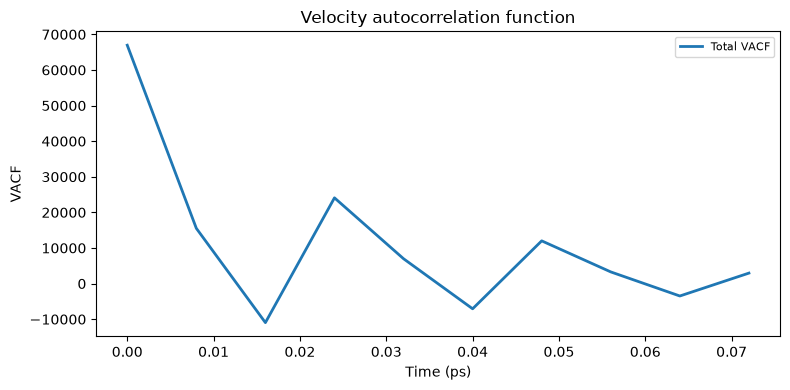

In [21]:
# VACF is available in vdos.totVACF[]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(vdos.tau, vdos.totVACF[0], linewidth=2.0, label="Total VACF")
ax.set(
    xlabel="Time (ps)",
    ylabel="VACF",
    title="Velocity autocorrelation function",
)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()